<div style="
    border: 2px solid #333;
    padding: 14px 20px;
    margin: 15px auto 25px auto;
    width: 85%;
    max-width: 900px;
    box-sizing: border-box;
    text-align: center;
">
    <h1 style="margin: 0;"><b>Camera Calibration</b></h1>
</div>

This notebook implements planar camera calibration from multiple chessboard images using Zhang's method.

The calibration estimates the camera intrinsic matrix from several views of a known planar pattern, recovers the camera pose for each view, and evaluates the calibration by measuring reprojection error.

## Problem Statement

A camera maps 3D world points to 2D image coordinates through a combination of **intrinsic** and **extrinsic** parameters.

For a planar calibration target, the goal is to estimate:

- the intrinsic matrix \(K\), containing the focal scale factors, skew, and principal point;
- the rotation matrix \(R\) and translation vector \(t\) for each calibration image.

The calibration is performed from several images of the same chessboard observed under different orientations.

A homography is first estimated between the chessboard plane and each image. These homographies provide constraints on the intrinsic camera parameters. Once the intrinsic matrix is known, the pose of the calibration plane can be recovered for every image.

## Objectives

1. Detect and refine chessboard corners in each calibration image.
2. Define the corresponding chessboard coordinates in the calibration plane.
3. Estimate a normalized homography for every valid image.
4. Build the linear constraint system used by Zhang's calibration method.
5. Estimate the intrinsic camera matrix \(K\).
6. Recover the extrinsic parameters \(R\) and \(t\) for each view.
7. Reproject the calibration points into the image.
8. Quantify calibration accuracy using reprojection error.

## Approach

The calibration follows the sequence below:

1. **Corner detection**  
   Detect the internal chessboard corners and refine their pixel coordinates to sub-pixel accuracy.

2. **Planar reference coordinates**  
   Assign physical coordinates to the chessboard corners using the known square size.

3. **Point normalization**  
   Normalize both image and planar points before solving for each homography. This improves the numerical conditioning of the Direct Linear Transform (DLT).

4. **Homography estimation**  
   Solve the homogeneous linear system using Singular Value Decomposition (SVD), then denormalize the resulting homography.

5. **Intrinsic calibration**  
   Use the homographies to construct the constraints on the symmetric matrix \(B = K^{-T}K^{-1}\). Solve the resulting system with SVD and recover the intrinsic parameters.

6. **Pose recovery**  
   Compute \(R\) and \(t\) for each calibration image from its homography and the estimated intrinsic matrix.

7. **Validation**  
   Reproject the chessboard points into each image and compare them with the detected corners. The residual distances are summarized using the mean reprojection error and RMSE.

## Calibration Assumptions

- The chessboard is planar.
- The internal corner pattern contains **8 columns × 6 rows**.
- Adjacent chessboard corners are separated by **0.03 m**.
- Lens distortion is not estimated in this implementation.
- The calibration images are stored in:

```text
data/calibration_images/
```

Because this notebook is located in `notebooks/`, the relative path used below is `../data/calibration_images/`.

## 0. Setup

Import the libraries used throughout the calibration workflow.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Keep numerical output compact while retaining useful precision.
np.set_printoptions(precision=6, suppress=True)

## 1. Data Path

Define and validate the directory containing the calibration images.

In [2]:
# The notebook is stored in Camera_Calibration/notebooks/.
DATA_DIR = Path("../data/calibration_images")

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Calibration image directory not found: {DATA_DIR}"
    )

# Process calibration images in filename order for reproducibility.
image_paths = sorted(DATA_DIR.glob("*.jpg"))

if not image_paths:
    raise FileNotFoundError(
        f"No .jpg calibration images found in: {DATA_DIR}"
    )

print(f"Calibration images found: {len(image_paths)}")
for path in image_paths:
    print(f"  - {path.name}")

Calibration images found: 9
  - img0.jpg
  - img1.jpg
  - img2.jpg
  - img3.jpg
  - img4.jpg
  - img5.jpg
  - img6.jpg
  - img7.jpg
  - img8.jpg


## 2. Output Directory

Define the directory used to store generated figures.

In [3]:
# Directory used to store generated figures.
OUTPUT_DIR = Path("../outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Utility Functions

Two basic operations are used repeatedly during homography estimation:

- conversion from Cartesian to homogeneous coordinates;
- similarity normalization of 2D point sets.

For normalized DLT, the point centroid is moved to the origin and the mean distance to the origin is scaled to \(\sqrt{2}\).

In [4]:
def homogenize(points):
    """Convert an array of 2D Cartesian points to homogeneous coordinates."""
    points = np.asarray(points, dtype=float)

    homogeneous = np.ones((points.shape[0], 3), dtype=float)
    homogeneous[:, :2] = points
    return homogeneous


def normalize_trans(points):
    """Return a similarity transform that normalizes a set of 2D points."""
    points = np.asarray(points, dtype=float)

    # Translate the centroid of the point cloud to the origin.
    centroid = np.mean(points, axis=0)
    shifted = points - centroid

    # Scale the mean distance from the origin to sqrt(2).
    distances = np.linalg.norm(shifted, axis=1)
    mean_distance = np.mean(distances)

    if mean_distance < 1e-12:
        raise ValueError(
            "Point normalization is undefined for coincident points."
        )

    scale = np.sqrt(2.0) / mean_distance

    return np.array(
        [
            [scale, 0.0, -scale * centroid[0]],
            [0.0, scale, -scale * centroid[1]],
            [0.0, 0.0, 1.0],
        ],
        dtype=float,
    )

## 4. Calibration Image Model

The `Image` class groups the operations associated with one calibration view:

- image loading;
- chessboard corner detection;
- planar point generation;
- normalized homography estimation;
- construction of Zhang's calibration constraints;
- recovery of the camera pose.

In [5]:
class Image:
    """Represent one planar calibration image and its geometric quantities."""

    # Termination criterion used by OpenCV for sub-pixel corner refinement.
    refine_criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        30,
        0.001,
    )

    def __init__(
        self,
        image_path,
        square_size=0.03,
        rows=8,
        cols=6,
    ):
        self.path = Path(image_path)
        self.square_size = float(square_size)
        self.rows = int(rows)
        self.cols = int(cols)
        self.im_name = self.path.stem

        # OpenCV loads colour images in BGR order.
        self.im = cv2.imread(str(self.path))

        if self.im is None:
            raise FileNotFoundError(
                f"Unable to read calibration image: {self.path}"
            )

        # Compute all geometric quantities associated with this view.
        self.im_pts = self.locate_landmark()
        self.plane_pts = self.get_landmark_world_coordinate()
        self.H = self.find_homography()

    def locate_landmark(self):
        """Detect and refine the internal chessboard corners."""
        gray = cv2.cvtColor(self.im, cv2.COLOR_BGR2GRAY)

        found, corners = cv2.findChessboardCorners(
            gray,
            (self.rows, self.cols),
            None,
        )

        if not found or corners is None:
            raise ValueError(
                f"Chessboard corners were not detected in {self.path.name}"
            )

        # Improve corner localization from pixel to sub-pixel precision.
        corners = cv2.cornerSubPix(
            gray,
            corners,
            (11, 11),
            (-1, -1),
            self.refine_criteria,
        )

        return corners.reshape(-1, 2)

    def get_landmark_world_coordinate(self):
        """Return planar chessboard coordinates in metres."""
        points = np.zeros(
            (self.rows * self.cols, 2),
            dtype=np.float64,
        )

        index = 0

        # The first corner is the planar origin.
        # X increases along the 8-corner direction and Y along the 6-corner direction.
        for y_index in range(self.cols):
            for x_index in range(self.rows):
                points[index, 0] = x_index * self.square_size
                points[index, 1] = y_index * self.square_size
                index += 1

        return points

    def find_homography(self):
        """Estimate the plane-to-image homography using normalized DLT."""
        T_image = normalize_trans(self.im_pts)
        T_plane = normalize_trans(self.plane_pts)

        # Transform both point sets into normalized coordinates.
        normalized_image = (
            T_image @ homogenize(self.im_pts).T
        ).T

        normalized_plane = (
            T_plane @ homogenize(self.plane_pts).T
        ).T

        n_points = normalized_image.shape[0]
        Q = np.zeros((2 * n_points, 9), dtype=float)

        # Each point correspondence contributes two linear equations.
        for i in range(n_points):
            X, Y, _ = normalized_plane[i]
            u, v, _ = normalized_image[i]

            Q[2 * i] = [
                X, Y, 1.0,
                0.0, 0.0, 0.0,
                -u * X, -u * Y, -u,
            ]

            Q[2 * i + 1] = [
                0.0, 0.0, 0.0,
                X, Y, 1.0,
                -v * X, -v * Y, -v,
            ]

        # Solve Qh = 0. The last right singular vector gives the
        # least-squares homogeneous solution for the homography.
        _, _, Vt = np.linalg.svd(Q)
        H_normalized = Vt[-1].reshape(3, 3)

        # Undo the point normalizations.
        H = (
            np.linalg.inv(T_image)
            @ H_normalized
            @ T_plane
        )

        if abs(H[2, 2]) < 1e-12:
            raise ValueError(
                f"Degenerate homography for {self.path.name}"
            )

        # Homographies are defined up to an arbitrary non-zero scale.
        H /= H[2, 2]
        return H

    @staticmethod
    def _v_ij(hi, hj):
        """Construct one six-element Zhang constraint vector."""
        return np.array(
            [
                hi[0] * hj[0],
                hi[0] * hj[1] + hi[1] * hj[0],
                hi[1] * hj[1],
                hi[2] * hj[0] + hi[0] * hj[2],
                hi[2] * hj[1] + hi[1] * hj[2],
                hi[2] * hj[2],
            ],
            dtype=float,
        )

    def construct_v(self):
        """Return the two independent intrinsic constraints for this homography."""
        h1 = self.H[:, 0]
        h2 = self.H[:, 1]

        v12 = self._v_ij(h1, h2)
        v11 = self._v_ij(h1, h1)
        v22 = self._v_ij(h2, h2)

        return np.vstack((v12, v11 - v22))

    def find_extrinsic(self, K):
        """Recover rotation R and translation t from K and the homography."""
        K_inv = np.linalg.inv(K)

        h1 = self.H[:, 0]
        h2 = self.H[:, 1]
        h3 = self.H[:, 2]

        # Use the first homography column to recover the common scale.
        scale = 1.0 / np.linalg.norm(K_inv @ h1)

        r1 = scale * (K_inv @ h1)
        r2 = scale * (K_inv @ h2)
        r3 = np.cross(r1, r2)

        # Numerical estimation does not guarantee a perfectly orthonormal rotation.
        # Project the approximate matrix onto the nearest valid rotation matrix.
        R_approx = np.column_stack((r1, r2, r3))
        U, _, Vt = np.linalg.svd(R_approx)
        R = U @ Vt

        # Enforce a proper rotation with determinant +1.
        if np.linalg.det(R) < 0:
            U[:, -1] *= -1
            R = U @ Vt

        t = scale * (K_inv @ h3)

        return R, t

## 5. Load Calibration Views

Each image is processed independently. Images in which the complete chessboard pattern cannot be detected are excluded from the calibration.

In [6]:
images = []

for image_path in image_paths:
    try:
        image = Image(
            image_path,
            square_size=0.03,
            rows=8,
            cols=6,
        )
        images.append(image)
        print(f"[OK]      {image_path.name}")

    except (FileNotFoundError, ValueError) as error:
        print(f"[SKIPPED] {image_path.name}: {error}")

# Zhang calibration requires multiple independent planar views.
if len(images) < 3:
    raise RuntimeError(
        "At least three valid calibration images are required."
    )

print(f"\nValid calibration views: {len(images)}")

[OK]      img0.jpg
[OK]      img1.jpg
[OK]      img2.jpg
[OK]      img3.jpg
[OK]      img4.jpg
[OK]      img5.jpg
[OK]      img6.jpg
[OK]      img7.jpg
[OK]      img8.jpg

Valid calibration views: 9


## 6. Verify Detected Corners

The detected corners are visualized before parameter estimation to verify consistent chessboard localization across all valid views.

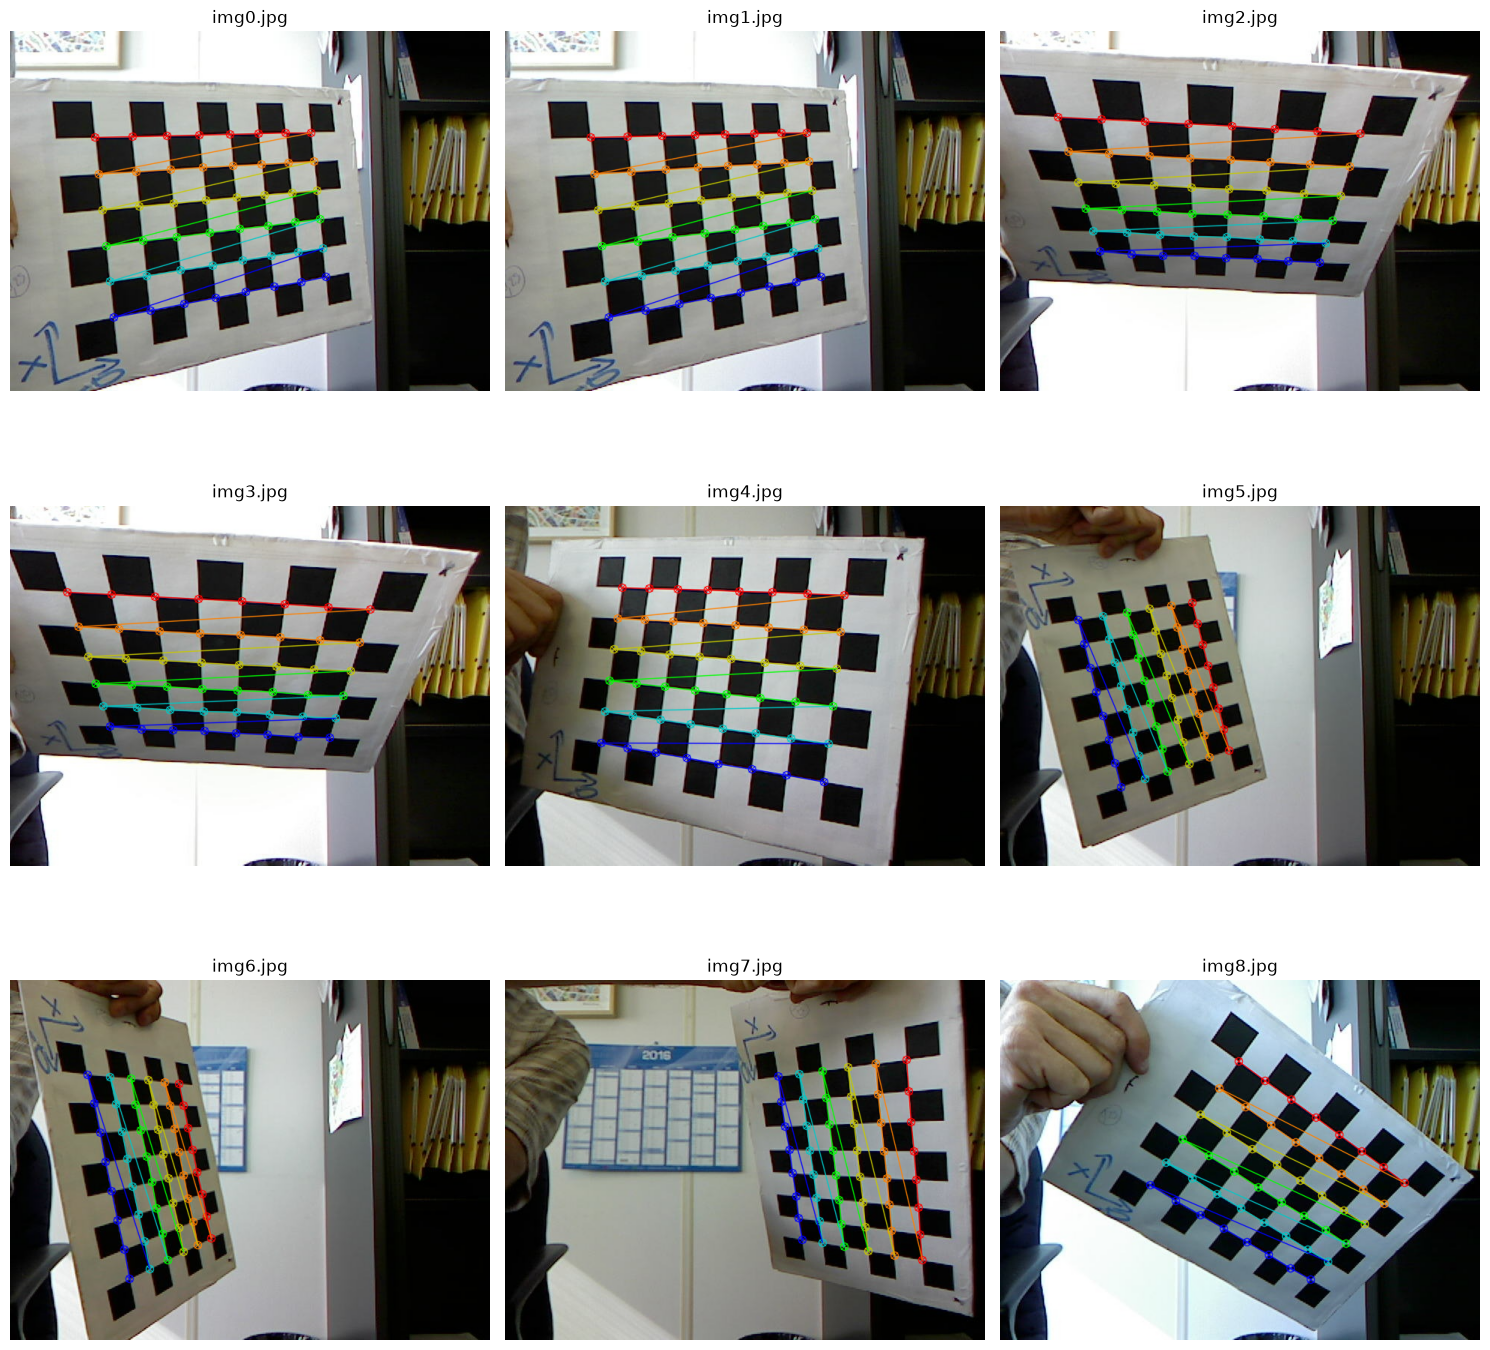

In [7]:
# Display detected chessboard corners for all valid calibration views.
n_images = len(images)
n_cols = 3
n_rows = int(np.ceil(n_images / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 5 * n_rows),
)

# Flatten axes to simplify iteration.
axes = np.asarray(axes).reshape(-1)

for ax, image in zip(axes, images):
    visual = image.im.copy()
    corners = image.im_pts.reshape(-1, 1, 2).astype(np.float32)

    # Draw the detected internal chessboard corners.
    cv2.drawChessboardCorners(
        visual,
        (image.rows, image.cols),
        corners,
        True,
    )

    # Convert OpenCV BGR format to RGB for Matplotlib.
    visual_rgb = cv2.cvtColor(
        visual,
        cv2.COLOR_BGR2RGB,
    )

    ax.imshow(visual_rgb)
    ax.set_title(image.path.name)
    ax.axis("off")

# Hide any unused axes in the last row.
for ax in axes[n_images:]:
    ax.axis("off")

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "detected_chessboard_corners.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 7. Homography Estimation

Each valid calibration view requires a homography between the planar chessboard coordinates and their detected image coordinates.

The diagram summarizes the normalized Direct Linear Transform used to estimate each homography.

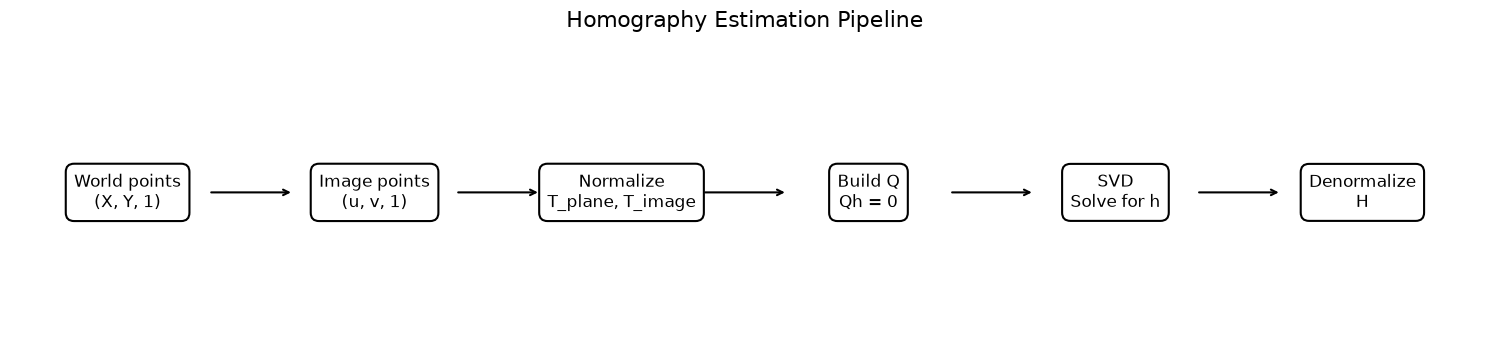

In [8]:
# Summarize the normalized DLT homography estimation pipeline.
fig, ax = plt.subplots(figsize=(15, 3.5))
ax.axis("off")

labels = [
    "World points\n(X, Y, 1)",
    "Image points\n(u, v, 1)",
    "Normalize\nT_plane, T_image",
    "Build Q\nQh = 0",
    "SVD\nSolve for h",
    "Denormalize\nH",
]

x_positions = np.linspace(0.08, 0.92, len(labels))

for x, label in zip(x_positions, labels):
    ax.text(
        x,
        0.5,
        label,
        ha="center",
        va="center",
        fontsize=12,
        transform=ax.transAxes,
        bbox={
            "boxstyle": "round,pad=0.5",
            "fill": False,
            "linewidth": 1.5,
        },
    )

for start, end in zip(x_positions[:-1], x_positions[1:]):
    ax.annotate(
        "",
        xy=(end - 0.055, 0.5),
        xytext=(start + 0.055, 0.5),
        xycoords=ax.transAxes,
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1.5,
        },
    )

ax.set_title("Homography Estimation Pipeline", fontsize=16, pad=20)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "homography_estimation_pipeline.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 8. Construct the Intrinsic Calibration System

For each homography \(H = [h_1 \; h_2 \; h_3]\), Zhang's method contributes two independent constraints. The constraints from all valid views are stacked into the matrix \(V\), and the homogeneous system \(Vb = 0\) is solved using SVD.

In [9]:
# Stack the two intrinsic constraints from every calibration view.
V = np.vstack([image.construct_v() for image in images])

# Solve Vb = 0 with SVD.
# The right singular vector associated with the smallest singular value
# gives the homogeneous least-squares solution.
_, singular_values, Vt = np.linalg.svd(V)
b = Vt[-1]

print("Constraint matrix shape:", V.shape)
print("\nSingular values:")
print(singular_values)

print("\nResidual norm ||Vb||:")
print(np.linalg.norm(V @ b))

print("\nEstimated b vector:")
print(b)

Constraint matrix shape: (18, 6)

Singular values:
[10570467.861231  9166881.090538  1672254.732288    10850.573156
     4170.700828        0.073745]

Residual norm ||Vb||:
0.07374462973551582

Estimated b vector:
[-0.000002  0.       -0.000002  0.000698  0.000516 -1.      ]


## 9. Estimate the Intrinsic Matrix

The estimated vector \(b\) contains the independent coefficients of \(B = K^{-T}K^{-1}\). The closed-form Zhang equations recover the focal scale factors, skew, principal point, and intrinsic camera matrix \(K\).

In [10]:
b11, b12, b22, b13, b23, b33 = b

denominator = b11 * b22 - b12**2

if abs(denominator) < 1e-12:
    raise ValueError("Degenerate intrinsic calibration constraints.")

# Recover the vertical principal-point coordinate.
v0 = (b12 * b13 - b11 * b23) / denominator

# Scale factor used by the closed-form intrinsic solution.
lam = b33 - (
    b13**2
    + v0 * (b12 * b13 - b11 * b23)
) / b11

# The homogeneous vector b is defined up to sign.
# Reverse it if needed so that the square-root terms remain physically valid.
if lam / b11 <= 0 or lam * b11 / denominator <= 0:
    b = -b
    b11, b12, b22, b13, b23, b33 = b

    denominator = b11 * b22 - b12**2
    v0 = (b12 * b13 - b11 * b23) / denominator

    lam = b33 - (
        b13**2
        + v0 * (b12 * b13 - b11 * b23)
    ) / b11

alpha = np.sqrt(lam / b11)
beta = np.sqrt(lam * b11 / denominator)

skew = -b12 * alpha**2 * beta / lam
u0 = skew * v0 / beta - b13 * alpha**2 / lam

K = np.array(
    [
        [alpha, skew, u0],
        [0.0, beta, v0],
        [0.0, 0.0, 1.0],
    ],
    dtype=float,
)

print("Intrinsic parameters")
print("--------------------")
print(f"alpha : {alpha:.6f}")
print(f"beta  : {beta:.6f}")
print(f"skew  : {skew:.6f}")
print(f"u0    : {u0:.6f}")
print(f"v0    : {v0:.6f}")

print("\nIntrinsic matrix K:")
print(K)

Intrinsic parameters
--------------------
alpha : 547.056831
beta  : 548.306822
skew  : 0.670827
u0    : 319.888557
v0    : 237.554629

Intrinsic matrix K:
[[547.056831   0.670827 319.888557]
 [  0.       548.306822 237.554629]
 [  0.         0.         1.      ]]


## 10. Estimate Camera Pose and Reprojection Error

For each calibration view, the homography and intrinsic matrix are used to recover \(R\) and \(t\). The calibration points are then reprojected into the image and compared with the detected corners.

In [11]:
calibration_results = []

for image in images:
    # Recover the pose of the calibration plane for this view.
    R, t = image.find_extrinsic(K)

    # Convert planar (X, Y) coordinates to 3D points with Z = 0.
    world_xy = image.get_landmark_world_coordinate()
    world_xyz = np.column_stack(
        (
            world_xy,
            np.zeros(world_xy.shape[0]),
        )
    )

    # Transform world points into the camera coordinate system.
    camera_points = world_xyz @ R.T + t

    # Apply the intrinsic matrix and convert homogeneous image
    # coordinates back to Cartesian pixel coordinates.
    projected_h = camera_points @ K.T
    projected_pixels = (
        projected_h[:, :2]
        / projected_h[:, 2:3]
    )

    # Pixel-space residuals between measured and predicted corner positions.
    residuals = projected_pixels - image.im_pts
    errors = np.linalg.norm(residuals, axis=1)

    calibration_results.append(
        {
            "name": image.path.name,
            "R": R,
            "t": t,
            "projected": projected_pixels,
            "errors": errors,
            "mean_error": float(errors.mean()),
            "rmse": float(np.sqrt(np.mean(errors**2))),
        }
    )

for result in calibration_results:
    print(result["name"])
    print("R =")
    print(result["R"])
    print("t =", result["t"])
    print(f"Mean reprojection error : {result['mean_error']:.4f} px")
    print(f"Reprojection RMSE       : {result['rmse']:.4f} px")
    print("-" * 60)

img0.jpg
R =
[[ 0.913569  0.100015 -0.394194]
 [-0.095269  0.994948  0.031648]
 [ 0.395368  0.008642  0.918482]]
t = [-0.128624 -0.05972   0.340668]
Mean reprojection error : 0.2561 px
Reprojection RMSE       : 0.3029 px
------------------------------------------------------------
img1.jpg
R =
[[ 0.913582  0.098342 -0.394584]
 [-0.094409  0.995099  0.029423]
 [ 0.395543  0.010372  0.918389]]
t = [-0.128361 -0.059664  0.34046 ]
Mean reprojection error : 0.2343 px
Reprojection RMSE       : 0.2772 px
------------------------------------------------------------
img2.jpg
R =
[[ 0.998455 -0.051583  0.020649]
 [ 0.050658  0.692462 -0.719674]
 [ 0.022825  0.719608  0.694005]]
t = [-0.125541 -0.063765  0.282383]
Mean reprojection error : 0.4690 px
Reprojection RMSE       : 0.5247 px
------------------------------------------------------------
img3.jpg
R =
[[ 0.99837  -0.05116   0.025314]
 [ 0.053681  0.690788 -0.721062]
 [ 0.019403  0.721245  0.692408]]
t = [-0.125603 -0.063131  0.28223 ]
Mean 

## 11. Camera Pose Visualization

The estimated camera centres are visualized relative to the planar chessboard reference frame to show the geometric diversity of the calibration viewpoints.

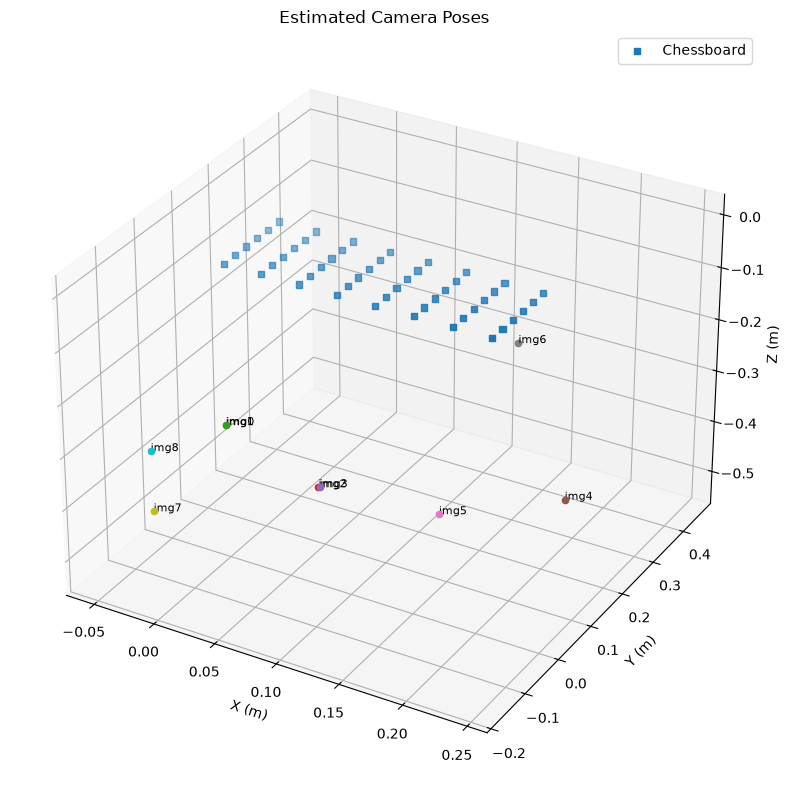

In [12]:
# Visualize the estimated camera centres relative to the chessboard plane.
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot chessboard reference points on the Z = 0 plane.
reference_xy = images[0].plane_pts
reference_xyz = np.column_stack(
    (
        reference_xy,
        np.zeros(reference_xy.shape[0]),
    )
)

ax.scatter(
    reference_xyz[:, 0],
    reference_xyz[:, 1],
    reference_xyz[:, 2],
    marker="s",
    label="Chessboard",
)

for image, result in zip(images, calibration_results):
    R = result["R"]
    t = result["t"]

    # For X_camera = R X_world + t, the camera centre in world
    # coordinates is C = -R^T t.
    camera_center = -R.T @ t

    ax.scatter(
        camera_center[0],
        camera_center[1],
        camera_center[2],
        marker="o",
    )

    ax.text(
        camera_center[0],
        camera_center[1],
        camera_center[2],
        image.path.stem,
        fontsize=8,
    )

ax.set_title("Estimated Camera Poses")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.legend()

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "estimated_camera_poses.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 12. Visualize Reprojection

Detected corners and reprojected corners are overlaid for every valid calibration image. Close agreement indicates geometric consistency.

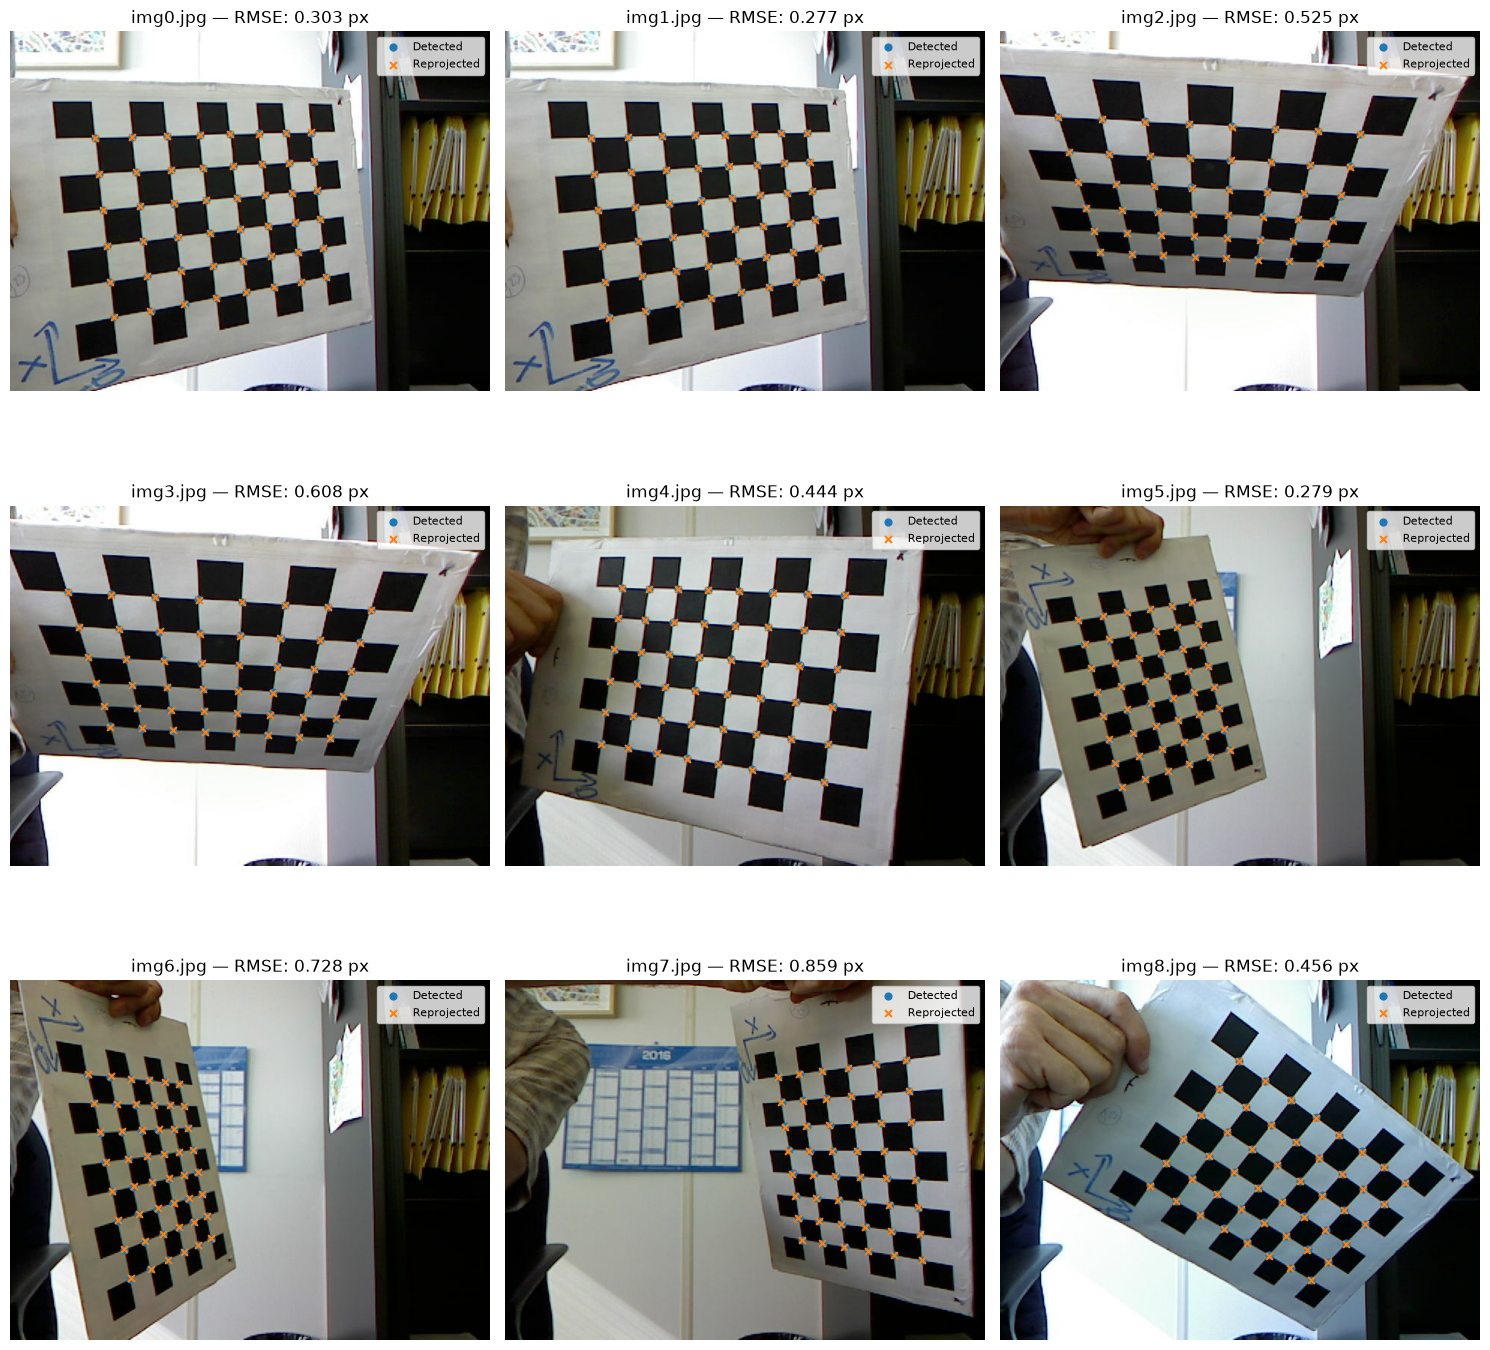

In [13]:
# Display detected and reprojected corners for all calibration views.
n_images = len(images)
n_cols = 3
n_rows = int(np.ceil(n_images / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 5 * n_rows),
)

axes = np.asarray(axes).reshape(-1)

for ax, (image, result) in zip(
    axes,
    zip(images, calibration_results),
):
    image_rgb = cv2.cvtColor(
        image.im,
        cv2.COLOR_BGR2RGB,
    )

    ax.imshow(image_rgb)

    # Observed corner positions.
    ax.scatter(
        image.im_pts[:, 0],
        image.im_pts[:, 1],
        s=24,
        marker="o",
        label="Detected",
    )

    # Corner positions predicted by the estimated camera model.
    ax.scatter(
        result["projected"][:, 0],
        result["projected"][:, 1],
        s=24,
        marker="x",
        label="Reprojected",
    )

    ax.set_title(
        f"{image.path.name} — RMSE: {result['rmse']:.3f} px"
    )
    ax.axis("off")
    ax.legend(fontsize=8)

for ax in axes[n_images:]:
    ax.axis("off")

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "reprojection_results.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 13. Overall Calibration Error

Aggregate the point-wise residuals from all valid views and compute the overall mean reprojection error and RMSE.

In [14]:
# Combine residual magnitudes from every valid calibration image.
all_errors = np.concatenate(
    [result["errors"] for result in calibration_results]
)

overall_mean_error = float(all_errors.mean())
overall_rmse = float(np.sqrt(np.mean(all_errors**2)))

print("Calibration summary")
print("-------------------")
print(f"Valid calibration views : {len(images)}")
print(f"Calibration points       : {len(all_errors)}")
print(f"Mean reprojection error  : {overall_mean_error:.4f} px")
print(f"Overall RMSE             : {overall_rmse:.4f} px")

Calibration summary
-------------------
Valid calibration views : 9
Calibration points       : 432
Mean reprojection error  : 0.4340 px
Overall RMSE             : 0.5339 px


## 14. Mean Reprojection Error by Calibration View

Compare the average reprojection error across calibration views to identify images with larger residuals.

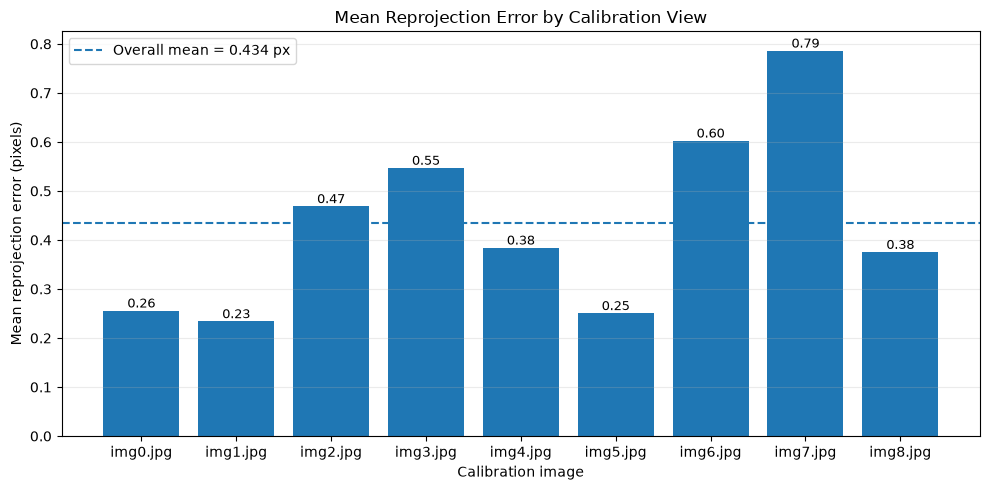

In [15]:
# Compare mean reprojection error across calibration views.
image_names = [
    result["name"]
    for result in calibration_results
]

mean_errors = [
    result["mean_error"]
    for result in calibration_results
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    image_names,
    mean_errors,
)

# The global mean provides a common reference across views.
ax.axhline(
    overall_mean_error,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall mean = {overall_mean_error:.3f} px",
)

for bar, value in zip(bars, mean_errors):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("Mean Reprojection Error by Calibration View")
ax.set_xlabel("Calibration image")
ax.set_ylabel("Mean reprojection error (pixels)")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "mean_reprojection_error_by_view.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 15. Reprojection Error Distribution

The distribution of point-wise reprojection errors provides a global view of residual calibration error and helps reveal unusually large deviations.

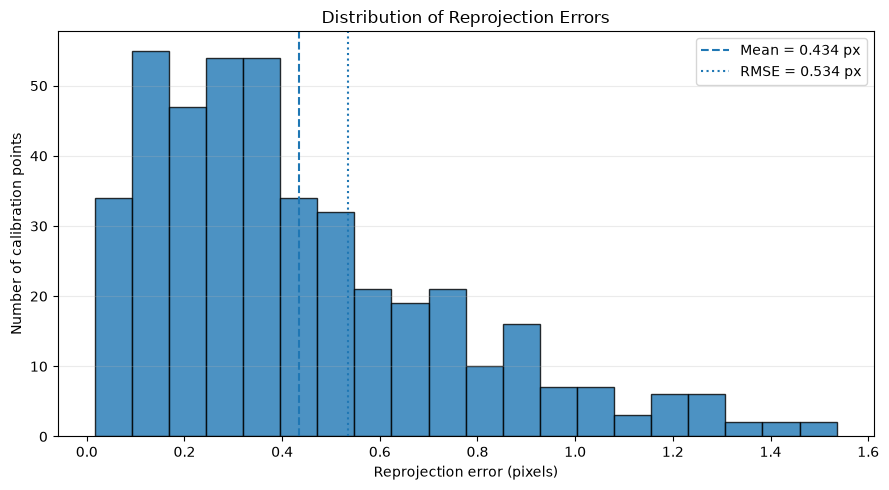

In [16]:
# Analyse the distribution of point-wise reprojection errors.
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    all_errors,
    bins=20,
    edgecolor="black",
    alpha=0.8,
)

ax.axvline(
    overall_mean_error,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean = {overall_mean_error:.3f} px",
)

ax.axvline(
    overall_rmse,
    linestyle=":",
    linewidth=1.5,
    label=f"RMSE = {overall_rmse:.3f} px",
)

ax.set_title("Distribution of Reprojection Errors")
ax.set_xlabel("Reprojection error (pixels)")
ax.set_ylabel("Number of calibration points")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "reprojection_error_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Discussion

The calibration is assessed from complementary geometric and numerical results:

- detected chessboard corners verify the measurements used by the algorithm;
- the homography diagram summarizes the normalized DLT procedure;
- estimated camera centres show the diversity of viewpoints;
- reprojection overlays compare observed and predicted corner positions;
- per-view mean errors reveal views with larger residuals;
- the error distribution summarizes point-wise residual behaviour.

This implementation does not estimate radial or tangential lens distortion. If distortion is significant, a model including distortion coefficients would be required.

## Conclusion

The calibration procedure estimates the camera intrinsic matrix from multiple planar chessboard views and recovers the pose associated with each image.

The estimated model is evaluated through point reprojection, per-view residual analysis, and the global distribution of reprojection errors.